# Susceptibilidad a movimientos en masa

© 2024 Exneyder A. Montoya-Araque, Daniel F. Ruiz y Universidad EAFIT.

Este notebook puede ejecutarse en línea → [![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AppliedMechanics-EAFIT/slope_stability/blob/main/notebooks/01_spatial_domain/01_conditioning_factors/landslide_susceptibility.ipynb)

La herramienta estima la susceptibilidad mediante el método del **valor informativo** y agrega las unidades computacionales del terreno (TCU) en unidades de zonificación (TZU), siguiendo a {cite:t}`Ciurleo_etal_2016_SusceptibilityZoningShallow`. Los datos de demostración proceden del material docente de la escuela LARAM 2023.

## Fundamentos

El valor informativo compara la densidad de movimientos en cada clase de un factor condicionante con la densidad media del inventario. Un peso positivo indica una asociación mayor que la media; el índice de susceptibilidad es la suma de los pesos de las clases presentes en cada celda. El índice expresa propensión espacial relativa, no probabilidad temporal de falla.

## Cómo usar la herramienta

1. Use `testing_data = True` para reproducir el ejemplo remoto o `False` para cargar rasters propios.
2. Identifique cuáles capas son continuas y cuáles son categóricas.
3. Compruebe CRS, extensión, origen, resolución y máscara común antes de combinar celdas.
4. Interprete el AUC junto con la cobertura espacial y valide con datos independientes cuando estén disponibles.

:::{warning}
La zonificación es un resultado dependiente del inventario, de la clasificación y de la escala. No sustituye un análisis de amenaza ni una evaluación geotécnica del sitio.
:::

## Módulos requeridos y configuración de figuras

In [ ]:
import os
import sys
import shutil
import subprocess
from IPython import get_ipython

if 'google.colab' in str(get_ipython()):
    print('Running in Google Colab. Installing the required modules...')
    from subprocess import run
    # run('pip install ipympl', shell=True);
    from google.colab import output, files
    output.enable_custom_widget_manager()
else:
    import tkinter as tk
    from tkinter.filedialog import askopenfilename
    
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.metrics import roc_curve, roc_auc_score
import rasterio
from rasterio.coords import BoundingBox
from rasterio.enums import Resampling
from rasterio.transform import array_bounds
from rasterio.warp import reproject
from rasterio.coords import BoundingBox
from rasterio.enums import Resampling
from rasterio.transform import array_bounds
from rasterio.warp import reproject

# Figure style shared by every chapter
plt.style.use("default")
AXIS_LINEWIDTH = 1.25
PLOT_LINEWIDTH = 1.75
mpl.rcParams.update(
    {
        "figure.constrained_layout.use": False,
        "figure.figsize": (6.4, 4.2),
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.family": "DejaVu Serif",
        "font.serif": ["DejaVu Serif"],
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "axes.linewidth": AXIS_LINEWIDTH,
        "axes.formatter.use_mathtext": True,
        "axes.unicode_minus": False,
        "lines.linewidth": PLOT_LINEWIDTH,
        "lines.markersize": 6,
        "grid.color": "0.75",
        "grid.linestyle": "--",
        "grid.linewidth": 0.6,
        "legend.frameon": False,
        "mathtext.fontset": "dejavuserif",
        "xtick.major.width": AXIS_LINEWIDTH,
        "ytick.major.width": AXIS_LINEWIDTH,
        "text.usetex": False,
    }
)
tol_cols = ["#004488", "#DDAA33", "#BB5566"]

n_classes = 8  # number of classes to divide the conditioning factors

## Funciones

In [2]:
def _grid(array, transform, crs, profile=None):
    return {
        "shape": array.shape,
        "transform": transform,
        "crs": crs,
        "profile": {} if profile is None else profile.copy(),
    }


def _same_grid(shape, transform, crs, reference, atol=1e-9):
    return (
        shape == reference["shape"]
        and crs == reference["crs"]
        and np.allclose(tuple(transform), tuple(reference["transform"]), atol=atol, rtol=0)
    )


def load_tiff(path, reference=None, categorical=False):
    """Read one band and, when requested, align it to a reference grid."""
    with rasterio.open(path) as src:
        source = src.read(1, masked=True).astype("float64")
        values = source.filled(np.nan)
        values[~np.isfinite(values)] = np.nan
        profile = src.profile.copy()

        if reference is not None and not _same_grid(
            values.shape, src.transform, src.crs, reference
        ):
            if src.crs is None or reference["crs"] is None:
                raise ValueError(
                    f"Raster {path!s} cannot be aligned because its CRS or the reference CRS is undefined."
                )
            aligned = np.full(reference["shape"], np.nan, dtype="float64")
            reproject(
                source=values,
                destination=aligned,
                src_transform=src.transform,
                src_crs=src.crs,
                src_nodata=np.nan,
                dst_transform=reference["transform"],
                dst_crs=reference["crs"],
                dst_nodata=np.nan,
                resampling=Resampling.nearest if categorical else Resampling.bilinear,
                init_dest_nodata=True,
            )
            values = aligned
            transform = reference["transform"]
            crs = reference["crs"]
        else:
            transform = src.transform
            crs = src.crs

    bounds = BoundingBox(*array_bounds(*values.shape, transform))
    return values, transform, crs, bounds, profile


def write_result(path, array, reference, nodata=-9999.0):
    """Write a floating-point result on the exact reference grid."""
    if array.shape != reference["shape"]:
        raise ValueError(f"Output shape {array.shape} differs from {reference['shape']}.")
    profile = reference["profile"].copy()
    profile.update(
        driver="GTiff",
        height=reference["shape"][0],
        width=reference["shape"][1],
        count=1,
        dtype="float32",
        transform=reference["transform"],
        crs=reference["crs"],
        nodata=nodata,
        compress="deflate",
    )
    output = np.where(np.isfinite(array), array, nodata).astype("float32")
    with rasterio.open(path, "w", **profile) as dst:
        dst.write(output, 1)


def plot_field(field, bounds, title=None, cmap="viridis"):
    valid_values = np.unique(np.asarray(field)[np.isfinite(field)])
    if valid_values.size == 0:
        raise ValueError("The raster has no finite values to plot.")
    fig, ax = plt.subplots()
    extent = (bounds.left, bounds.right, bounds.bottom, bounds.top)
    if valid_values.size > n_classes:
        image = ax.imshow(field, cmap=cmap, extent=extent)
        fig.colorbar(image, ax=ax, label=title)
    else:
        field_reclassified, ticks, discrete_cmap = extract_from_discrete(field, cmap)
        image = ax.imshow(field_reclassified, cmap=discrete_cmap, extent=extent)
        colorbar = fig.colorbar(image, ax=ax, label=title, ticks=np.arange(ticks.size))
        colorbar.ax.set_yticklabels([f"{value:g}" for value in ticks])
    ax.set(xlabel="Easting [m]", ylabel="Northing [m]")
    fig.canvas.header_visible = False
    fig.canvas.toolbar_position = "bottom"
    plt.show()
    return fig


def extract_from_discrete(field, cmap="viridis"):
    ticks = np.unique(np.asarray(field)[np.isfinite(field)])
    field_reclassified = np.full_like(field, np.nan, dtype=float)
    for index, value in enumerate(ticks):
        field_reclassified[field == value] = index
    discrete_cmap = plt.colormaps.get_cmap(cmap).resampled(ticks.size)
    return field_reclassified, ticks, discrete_cmap


def nan_gaussian_filter(data, sigma):
    nan_mask = ~np.isfinite(data)
    data_filled = np.where(nan_mask, 0.0, data)
    weights = (~nan_mask).astype(float)
    filtered = sp.ndimage.gaussian_filter(data_filled, sigma=sigma, mode="constant", cval=0.0)
    filtered_weights = sp.ndimage.gaussian_filter(weights, sigma=sigma, mode="constant", cval=0.0)
    with np.errstate(invalid="ignore", divide="ignore"):
        normalized = np.divide(
            filtered,
            filtered_weights,
            out=np.full_like(filtered, np.nan),
            where=filtered_weights > 0,
        )
    normalized[nan_mask] = np.nan
    return normalized

## Lectura de datos de entrada
En Google Colab, use `testing_data = False` para cargar sus propios archivos raster con el selector que aparecerá.

In [3]:
testing_data = True  # Set to False to use the GUI to load the data from an external file

local_data = False  # Set to True to load the data from a local directory either in Colab or in a local machine.

if local_data:
    local_folder_conditioning_factors = "local_folder_conditioning_factors/"
    local_folder_inventory = "local_folder_inventory/"
    os.makedirs(local_folder_conditioning_factors, exist_ok=True)
    os.makedirs(local_folder_inventory, exist_ok=True)
else:
    local_folder_conditioning_factors = "./"
    local_folder_inventory = "./"

### Carga de datos de prueba

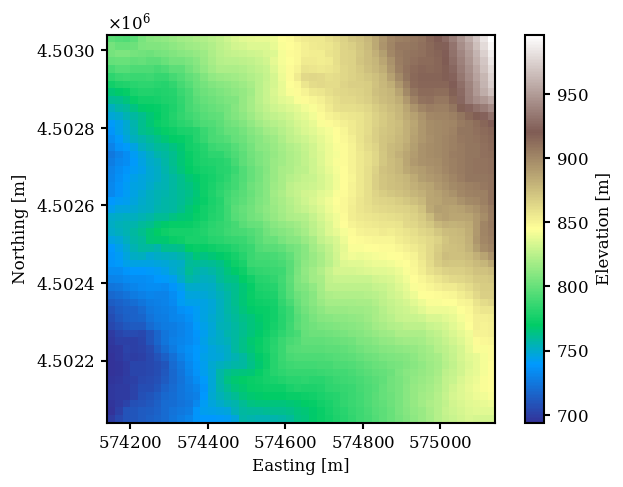

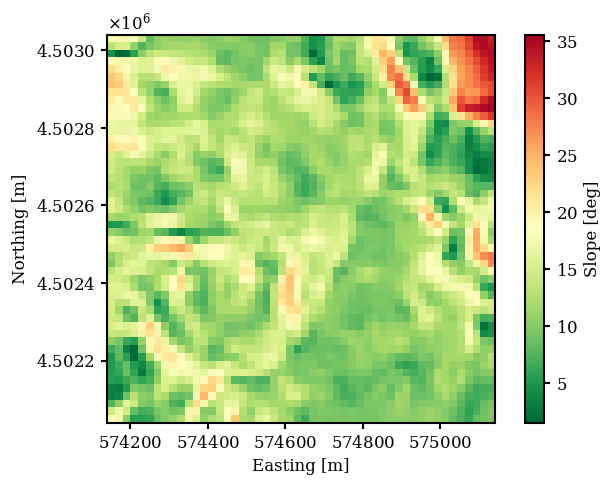

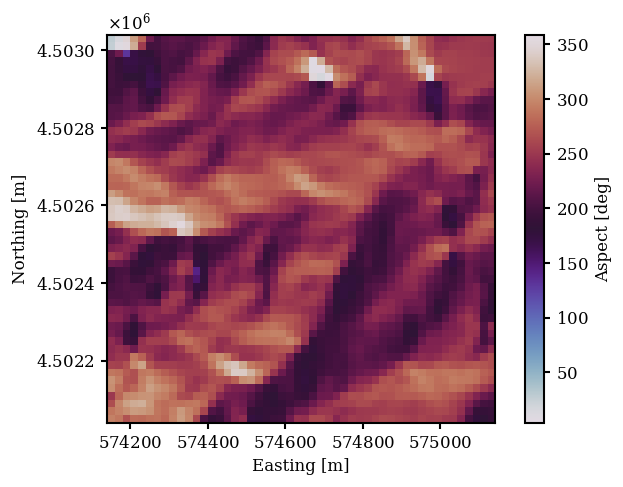

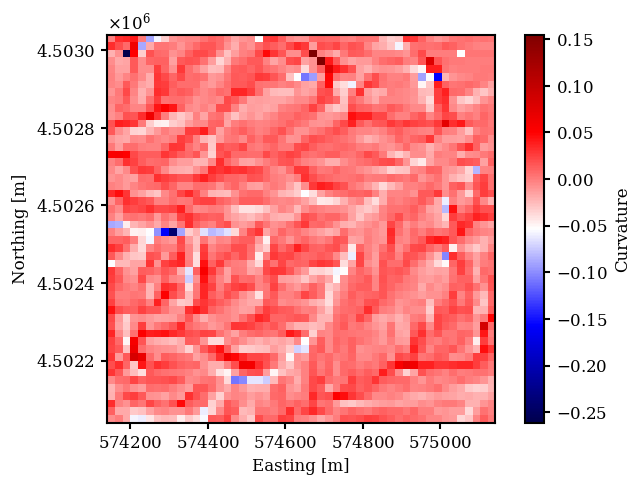

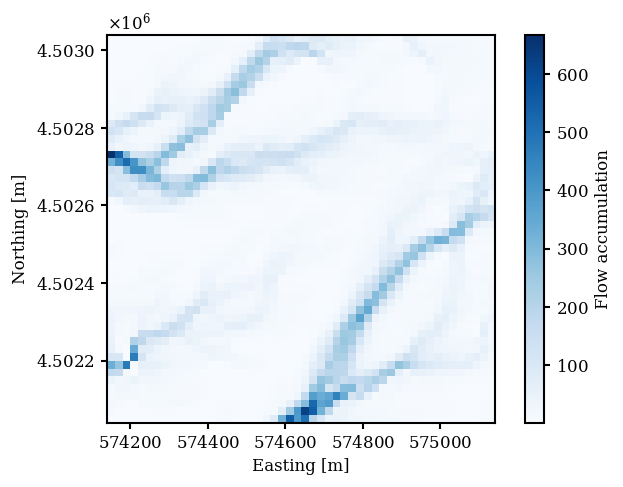

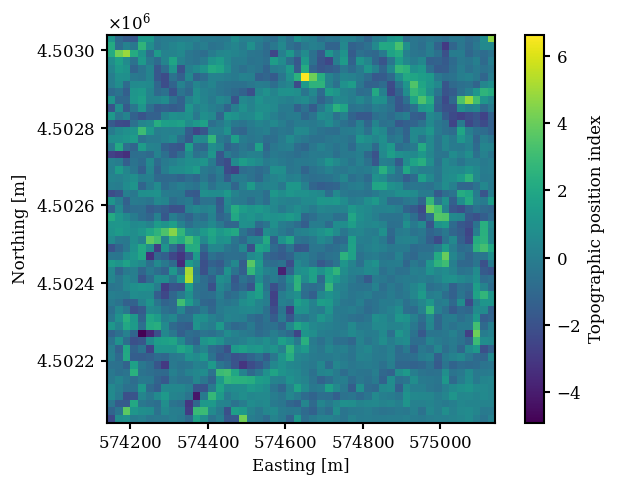

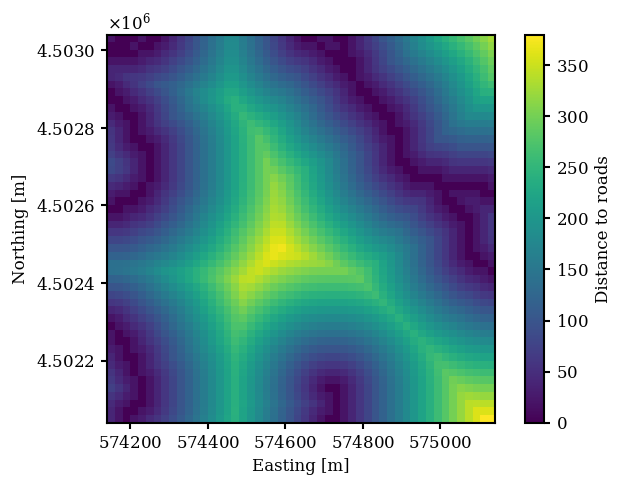

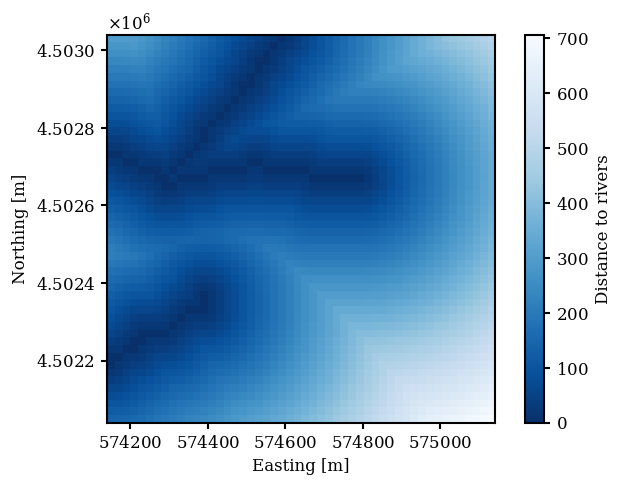

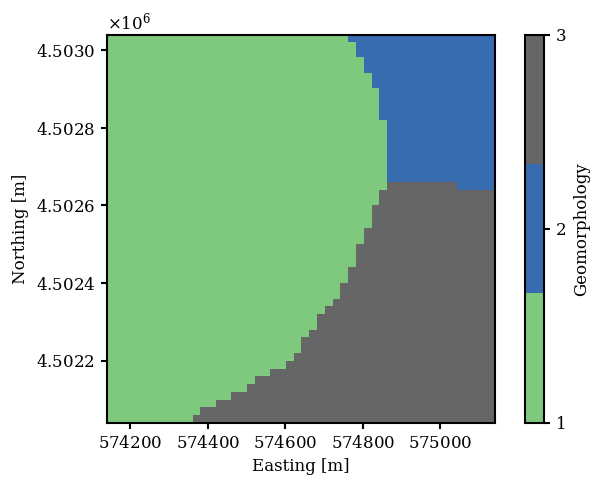

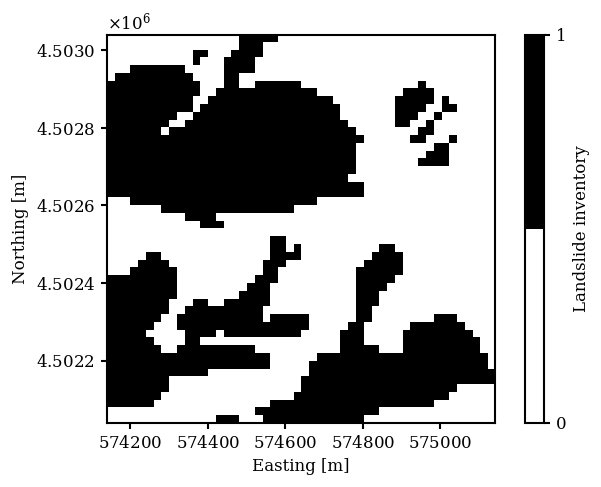

In [5]:
if testing_data:
    base_url = "https://raw.githubusercontent.com/eamontoyaa/data4testing/main/susceptibility"
    conditioning_paths = {
        "elevation": f"{base_url}/elevation.tif",
        "slope": f"{base_url}/slope.tif",
        "aspect": f"{base_url}/aspect.tif",
        "curvature": f"{base_url}/curvature.tif",
        "flow_acc": f"{base_url}/flow_acc.tif",
        "tpi": f"{base_url}/tpi.tif",
        "roads_prox": f"{base_url}/roads_prox.tif",
        "rivers_prox": f"{base_url}/rivers_prox.tif",
        "geomorphology": f"{base_url}/geomorphology.tif",
    }

    elevation, transform, crs, bounds, profile = load_tiff(conditioning_paths["elevation"])
    reference_grid = _grid(elevation, transform, crs, profile)
    conditioning = {"elevation": elevation}
    for name, path in list(conditioning_paths.items())[1:]:
        conditioning[name], _, _, _, _ = load_tiff(
            path,
            reference=reference_grid,
            categorical=name == "geomorphology",
        )

    df_cond_fact = pd.DataFrame(
        {name: values.ravel() for name, values in conditioning.items()}
    )
    independent_vars = df_cond_fact.columns.to_list()
    independent_vars_types = ["d" if name == "geomorphology" else "c" for name in independent_vars]

    landslides, _, _, _, _ = load_tiff(
        f"{base_url}/landslides.tif",
        reference=reference_grid,
        categorical=True,
    )
    # Inventory rasters commonly store only mapped landslides and encode the
    # remaining terrain as nodata. Within the conditioning-factor domain,
    # nodata therefore represents absence (0), not an invalid analysis cell.
    landslides = np.where(landslides == 1, 1.0, 0.0)
    df_landslides = pd.Series(landslides.ravel(), name="landslide")

    plot_specs = {
        "elevation": ("Elevation [m]", "terrain"),
        "slope": ("Slope [deg]", "RdYlGn_r"),
        "aspect": ("Aspect [deg]", "twilight"),
        "curvature": ("Curvature", "seismic"),
        "flow_acc": ("Flow accumulation", "Blues"),
        "tpi": ("Topographic position index", "viridis"),
        "roads_prox": ("Distance to roads", "viridis"),
        "rivers_prox": ("Distance to rivers", "Blues_r"),
        "geomorphology": ("Geomorphology", "Accent"),
    }
    for name, (label, cmap_name) in plot_specs.items():
        plot_field(conditioning[name], bounds, title=label, cmap=cmap_name)
    plot_field(landslides, bounds, title="Landslide inventory", cmap="binary")

### Carga de rasters de factores condicionantes

In [6]:
if not testing_data:
    outputs_folder = "outputs"
    os.makedirs(outputs_folder, exist_ok=True)
    if not local_data:
        uploaded = files.upload()
        conditioning_files = [os.path.join(os.getcwd(), name) for name in uploaded]
    else:
        conditioning_files = [
            os.path.join(local_folder_conditioning_factors, name)
            for name in sorted(os.listdir(local_folder_conditioning_factors))
        ]
    conditioning_files = [path for path in conditioning_files if path.lower().endswith((".tif", ".tiff"))]
    if not conditioning_files:
        raise FileNotFoundError("No conditioning-factor GeoTIFF files were provided.")

    df_cond_fact = pd.DataFrame()
    reference_grid = None
    for path in conditioning_files:
        file_name = os.path.splitext(os.path.basename(path))[0].split(" ")[0]
        raster, transform, crs, bounds, profile = load_tiff(
            path,
            reference=reference_grid,
            categorical=False,
        )
        if reference_grid is None:
            reference_grid = _grid(raster, transform, crs, profile)
        print(f"Loaded {file_name}: shape={raster.shape}, resolution={reference_grid['transform'].a:g}")
        plot_field(raster, bounds, title=file_name)
        df_cond_fact[file_name] = raster.ravel()

    independent_vars = df_cond_fact.columns.to_list()
    independent_vars_types = [
        "d" if df_cond_fact[name].nunique(dropna=True) <= n_classes else "c"
        for name in independent_vars
    ]

### Carga del raster del inventario 

In [7]:
if not testing_data:
    if not local_data:
        uploaded_inventory = files.upload()
        inventory_files = [os.path.join(os.getcwd(), name) for name in uploaded_inventory]
    else:
        inventory_files = [
            os.path.join(local_folder_inventory, name)
            for name in sorted(os.listdir(local_folder_inventory))
        ]
    inventory_files = [path for path in inventory_files if path.lower().endswith((".tif", ".tiff"))]
    if len(inventory_files) != 1:
        raise ValueError("Provide exactly one landslide-inventory GeoTIFF.")

    landslides, _, _, _, _ = load_tiff(
        inventory_files[0],
        reference=reference_grid,
        categorical=True,
    )
    # Accept both conventional 0/1 inventories and presence-only rasters.
    landslides = np.where(landslides == 1, 1.0, 0.0)
    df_landslides = pd.Series(landslides.ravel(), name="landslide")
    plot_field(landslides, bounds, title="Landslide inventory", cmap="binary")

In [8]:
mask_nan = df_cond_fact.isna().any(axis=1) | df_landslides.isna()
df_cond_fact.loc[mask_nan, :] = np.nan
df_landslides.loc[mask_nan] = np.nan
mask_nan_mtx = mask_nan.to_numpy().reshape(reference_grid["shape"])

if (~mask_nan).sum() == 0:
    raise ValueError("The raster stack has no cells that are valid in every input layer.")
if df_landslides.loc[~mask_nan].nunique() < 2:
    raise ValueError("The valid inventory must contain both stable and landslide cells.")

In [9]:
df_cond_fact

,elevation,slope,aspect,curvature,flow_acc,tpi,roads_prox,rivers_prox,geomorphology
0,797.760010,18.761023,27.847687,-0.00147,2.12,1.128723,20.0,300.000000,1.0
1,794.750000,17.574442,15.301435,0.03129,3.20,-0.911255,0.0,300.000000,1.0
2,794.169983,17.088249,348.047455,0.03405,5.56,-1.530029,0.0,300.665924,1.0
3,797.669983,17.850204,311.438507,0.04068,3.59,-1.732483,0.0,297.321381,1.0
4,805.789978,14.410152,279.945099,0.00059,1.69,1.342468,20.0,284.253418,1.0
...,...,...,...,...,...,...,...,...,...
2495,831.929993,7.303904,235.462631,-0.03553,2.60,0.393738,320.0,672.309448,3.0
2496,833.359985,6.323634,200.697632,-0.03034,2.37,0.659973,340.0,680.294067,3.0
2497,833.030029,8.246736,176.506042,-0.00403,4.16,0.075073,360.0,688.767029,3.0
2498,832.500000,9.393118,181.905396,0.01264,7.15,-0.397461,380.0,697.710571,3.0


In [10]:
independent_vars_types

['c', 'c', 'c', 'c', 'c', 'c', 'c', 'c', 'd']

In [11]:
df_landslides

0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
2495    0.0
2496    0.0
2497    0.0
2498    0.0
2499    0.0
Name: landslide, Length: 2500, dtype: float64

## Clase percentil de cada variable independiente

Las variables independientes continuas se clasifican por cuantiles en ocho clases.

In [12]:
df_cond_fact_p = pd.DataFrame(index=df_cond_fact.index)
n_class_by_var = {}

for variable, variable_type in zip(independent_vars, independent_vars_types):
    classes = np.full(len(df_cond_fact), -1, dtype=int)
    valid = df_cond_fact[variable].notna()
    if variable_type == "c":
        classes[valid] = pd.qcut(
            df_cond_fact.loc[valid, variable],
            q=n_classes,
            labels=False,
            duplicates="drop",
        ).astype(int)
    elif variable_type == "d":
        classes[valid] = pd.Categorical(df_cond_fact.loc[valid, variable]).codes
    else:
        raise ValueError(f"Unknown variable type {variable_type!r} for {variable!r}.")
    n_class_by_var[variable] = int(classes[valid].max() + 1)
    df_cond_fact_p[variable] = classes

df_cond_fact_p.loc[mask_nan, :] = -1
df_cond_fact_p

,elevation,slope,aspect,curvature,flow_acc,tpi,roads_prox,rivers_prox,geomorphology
0,3,7,0,3,0,7,0,5,0
1,3,7,0,7,0,1,0,5,0
2,3,6,7,7,1,0,0,6,0
3,3,7,7,7,1,0,0,5,0
4,3,5,7,3,0,7,0,5,0
...,...,...,...,...,...,...,...,...,...
2495,5,0,3,0,0,5,7,7,2
2496,5,0,0,0,0,6,7,7,2
2497,5,0,0,2,1,4,7,7,2
2498,5,1,0,6,2,2,7,7,2


### $N_{ij} = F_{ij} + NF_{ij}$ → TCU pertenecientes a la clase $j$ de la variable independiente $V_i$

- $F_{ij}$ → Número de TCU con movimientos en masa en la clase $j$ de la variable independiente $V_i$
- $NF_{ij}$ → Número de TCU sin movimientos en masa en la clase $j$ de la variable independiente $V_i$

In [13]:
max_classes = max(n_class_by_var.values())
Fij = np.full((max_classes, len(independent_vars)), np.nan)
NFij = np.full_like(Fij, np.nan)

for column, variable in enumerate(independent_vars):
    for class_id in range(n_class_by_var[variable]):
        in_class = df_cond_fact_p[variable] == class_id
        Fij[class_id, column] = np.sum(in_class & (df_landslides == 1))
        NFij[class_id, column] = np.sum(in_class & (df_landslides == 0))

Nij = Fij + NFij
pd.DataFrame(Nij, columns=independent_vars, index=[f"Class {i}" for i in range(max_classes)])

,elevation,slope,aspect,curvature,flow_acc,tpi,roads_prox,rivers_prox,geomorphology
Class 0,313.0,313.0,313.0,314.0,317.0,313.0,331.0,315.0,1493.0
Class 1,312.0,312.0,312.0,311.0,309.0,312.0,296.0,318.0,297.0
Class 2,312.0,312.0,312.0,312.0,311.0,313.0,311.0,307.0,708.0
Class 3,312.0,312.0,312.0,314.0,312.0,311.0,317.0,309.0,NaN
Class 4,312.0,312.0,312.0,311.0,312.0,312.0,306.0,313.0,NaN
Class 5,312.0,312.0,312.0,311.0,312.0,312.0,313.0,311.0,NaN
Class 6,313.0,312.0,312.0,312.0,312.0,312.0,312.0,312.0,NaN
Class 7,312.0,313.0,313.0,313.0,313.0,313.0,312.0,313.0,NaN


### $W_{ij} = \log\left(\frac{D_{ij}}{D^*}\right)$ → Peso de la clase $j$ de la variable independiente $V_i$

- $D_{ij} =\frac{F_{ij}}{N_{ij}}$ → Densidad de movimientos en la clase $j$ de la variable independiente $V_i$
- $D^* = \frac{F_\mathrm{tot}}{N_\mathrm{tot}}$ → Densidad media de movimientos en el área de estudio

In [14]:
Ftot = np.nansum(Fij, axis=0)
NFtot = np.nansum(NFij, axis=0)
Ntot = Ftot + NFtot
if np.any(Ftot == 0) or np.any(NFtot == 0):
    raise ValueError("Each factor requires valid cells with and without mapped landslides.")

with np.errstate(divide="ignore", invalid="ignore"):
    Dij = np.divide(Fij, Nij, out=np.full_like(Fij, np.nan), where=Nij > 0)
    Dast = Ftot / Ntot
    Wij = np.log10(Dij / Dast)

for column in range(Wij.shape[1]):
    finite = np.isfinite(Wij[:, column])
    zero_density = np.isneginf(Wij[:, column])
    if not finite.any():
        raise ValueError(f"No finite information weights for {independent_vars[column]!r}.")
    Wij[zero_density, column] = np.min(Wij[finite, column])

pd.DataFrame(Wij, columns=independent_vars, index=[f"Class {i}" for i in range(max_classes)])

,elevation,slope,aspect,curvature,flow_acc,tpi,roads_prox,rivers_prox,geomorphology
Class 0,0.185269,-0.046799,-0.105777,-0.273494,-0.489927,0.048730,-0.103268,0.259997,0.081188
Class 1,0.076936,0.063735,0.021537,-0.095168,-0.137263,0.036063,0.035445,0.198130,-0.544598
Class 2,0.159571,0.050119,-0.018675,-0.005901,-0.148751,0.037522,-0.017281,0.054361,-0.062326
Class 3,0.074328,0.063735,-0.015446,-0.031284,-0.070233,0.091142,-0.028833,-0.116278,NaN
Class 4,0.094769,0.044552,-0.045410,0.040305,0.018573,0.003439,0.044497,-0.228092,NaN
Class 5,0.018573,0.018573,-0.035190,0.067802,0.097258,-0.012241,0.043162,-0.454190,NaN
Class 6,-0.943050,-0.031837,0.092266,0.074328,0.135253,-0.041976,0.066407,-0.300682,NaN
Class 7,-0.614301,-0.233356,0.072938,0.112901,0.238436,-0.233356,-0.059420,0.093379,NaN


### $IS_\mathrm{TCU} = \sum_{i=0}^{n-1} W_{ik_{(i)}} $ → Índice de susceptibilidad

In [15]:
df_cond_fact_w = pd.DataFrame(index=df_cond_fact.index)
for column, variable in enumerate(independent_vars):
    classes = df_cond_fact_p[variable].to_numpy()
    weights = np.full(classes.shape, np.nan, dtype=float)
    valid = classes >= 0
    weights[valid] = Wij[classes[valid], column]
    df_cond_fact_w[variable] = weights

df_cond_fact_w["ISTCU"] = df_cond_fact_w[independent_vars].sum(axis=1, min_count=len(independent_vars))
df_cond_fact_w.loc[mask_nan, :] = np.nan
df_cond_fact_w

,elevation,slope,aspect,curvature,flow_acc,tpi,roads_prox,rivers_prox,geomorphology,ISTCU
0,0.074328,-0.233356,-0.105777,-0.031284,-0.489927,-0.233356,-0.103268,-0.454190,0.081188,-1.495642
1,0.074328,-0.233356,-0.105777,0.112901,-0.489927,0.036063,-0.103268,-0.454190,0.081188,-1.082037
2,0.074328,-0.031837,0.072938,0.112901,-0.137263,0.048730,-0.103268,-0.300682,0.081188,-0.182964
3,0.074328,-0.233356,0.072938,0.112901,-0.137263,0.048730,-0.103268,-0.454190,0.081188,-0.537991
4,0.074328,0.018573,0.072938,-0.031284,-0.489927,-0.233356,-0.103268,-0.454190,0.081188,-1.064998
...,...,...,...,...,...,...,...,...,...,...
2495,0.018573,-0.046799,-0.015446,-0.273494,-0.489927,-0.012241,-0.059420,0.093379,-0.062326,-0.847703
2496,0.018573,-0.046799,-0.105777,-0.273494,-0.489927,-0.041976,-0.059420,0.093379,-0.062326,-0.967769
2497,0.018573,-0.046799,-0.105777,-0.005901,-0.137263,0.003439,-0.059420,0.093379,-0.062326,-0.302096
2498,0.018573,0.063735,-0.105777,0.074328,-0.148751,0.037522,-0.059420,0.093379,-0.062326,-0.088738


## $\sigma_i$ → indicador estadístico de la capacidad discriminante de $W_i$

In [16]:
weighted_mean = np.nansum(Wij * Nij, axis=0) / np.nansum(Nij, axis=0)
sigma = np.sqrt(
    np.nansum(Nij * (Wij - weighted_mean) ** 2, axis=0)
    / np.nansum(Nij, axis=0)
)
sigma_sorted = pd.Series(sigma, index=independent_vars).sort_values(ascending=False)
sigma_sorted

elevation        0.393134
rivers_prox      0.237617
flow_acc         0.211544
geomorphology    0.197876
curvature        0.116288
slope            0.093608
tpi              0.093029
aspect           0.060477
roads_prox       0.056211
dtype: float64

/tmp/ipykernel_61337/960857723.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sigma_sorted.index, rotation=45, ha='right')


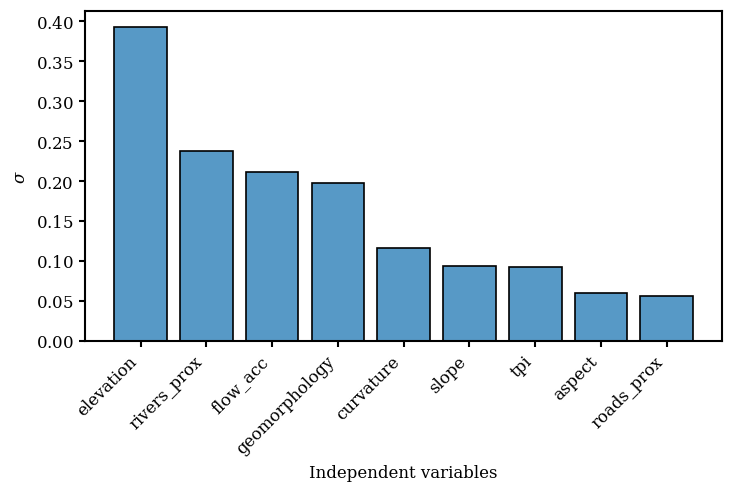

In [17]:
# Bar plot representing sigma
fig, ax = plt.subplots(figsize=(6, 4), layout='constrained')
ax.bar(sigma_sorted.index, sigma_sorted.values,
       color=mpl.colors.to_rgba('C0', alpha=0.75), edgecolor='black')
ax.set(ylabel='$\\sigma$', xlabel='Independent variables')
# rotate x labels
ax.set_xticklabels(sigma_sorted.index, rotation=45, ha='right')

ax.spines[["bottom", "left"]].set_linewidth(AXIS_LINEWIDTH)
ax.tick_params(width=AXIS_LINEWIDTH)
fig.canvas.header_visible = False
fig.canvas.toolbar_position = 'bottom'
plt.show()

## Distribución espacial del índice de susceptibilidad

In [18]:
# Define your colors
colors = ['xkcd:dull green', 'xkcd:dull yellow', 'xkcd:dull pink']
# Create a colormap
cmap = mpl.colors.LinearSegmentedColormap.from_list("custom_dull_cmap", colors)

### Resultado por unidades computacionales del terreno (TCU)

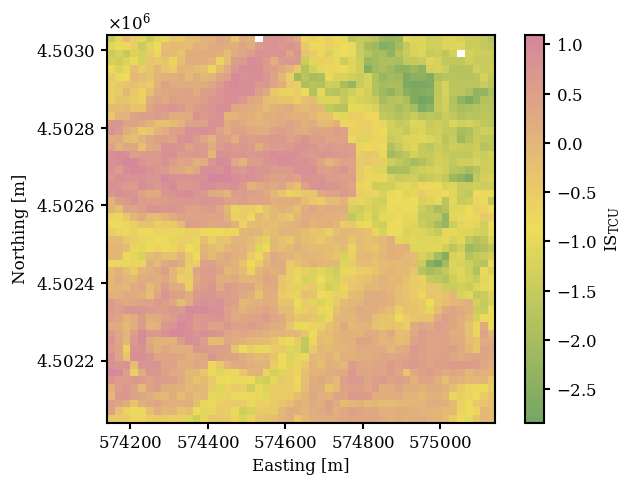

In [19]:
ISTCU = np.reshape(df_cond_fact_w['ISTCU'].to_numpy(), landslides.shape)

fig = plot_field(ISTCU, bounds, title='IS$_\\mathrm{TCU}$', cmap=cmap)#'Spectral_r')

### Resultado agregado por unidades de zonificación del terreno (TZU)

La estadística focal usa un filtro gaussiano bidimensional cuya desviación estándar $\sigma$ controla el grado de suavizado.

Para superponer los límites del inventario, active el código comentado en la celda siguiente.

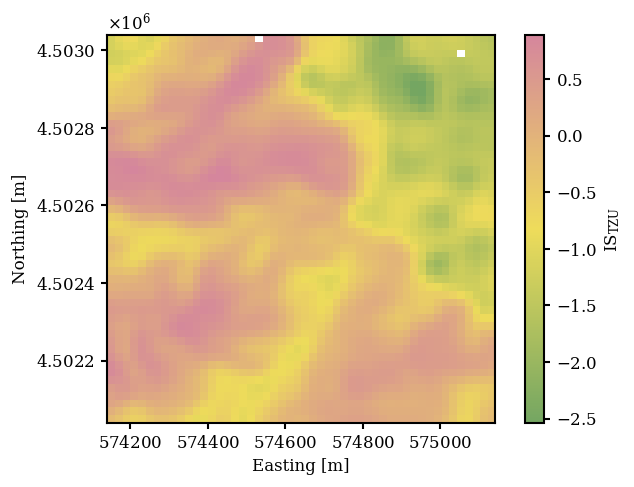

In [20]:
ISTZU = nan_gaussian_filter(ISTCU, sigma=1)

mask_nan_border = np.isnan(ISTZU).flatten()
df_cond_fact_w["ISTZU"] = ISTZU.flatten()

fig = plot_field(ISTZU, bounds, title='IS$_\\mathrm{TZU}$', cmap=cmap)#'Spectral_r')

# ax = fig.gca()
# ax.contour(landslides, colors='black', alpha=0.5, origin='image', levels=0, linewidths=5,
#            extent=(bounds.left, bounds.right, bounds.bottom, bounds.top))

### Exportación de resultados a raster

Active la exportación en la celda siguiente para guardar el índice de susceptibilidad como raster.

In [21]:
want_to_save = not testing_data
if want_to_save:
    write_result(os.path.join(outputs_folder, "ISTZU.tif"), ISTZU, reference_grid)

## Evaluación del desempeño del modelo

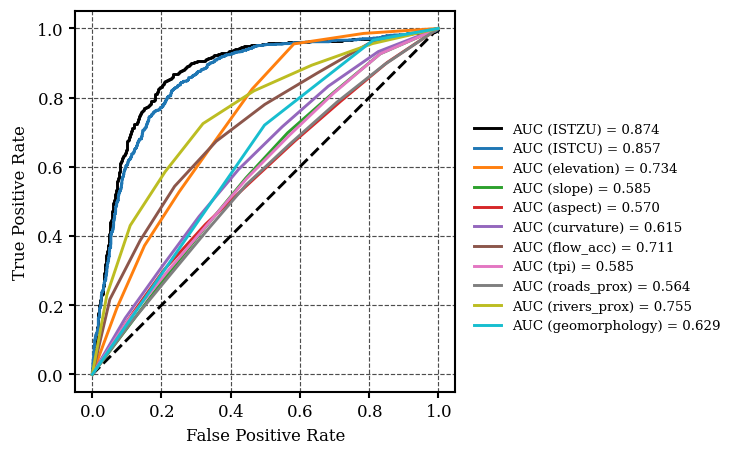

In [30]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6, 7.5), layout='constrained')
plt.plot([0, 1], [0, 1], 'k--')

fpr, tpr, thresholds = roc_curve(df_landslides.loc[~mask_nan], df_cond_fact_w.loc[~mask_nan, "ISTZU"])  # Calculate the ROC curve
auc_score = roc_auc_score(df_landslides.loc[~mask_nan], df_cond_fact_w.loc[~mask_nan, "ISTZU"])  # Calculate the AUC score
ax.plot(fpr, tpr, label=f'AUC (ISTZU) = {auc_score:.3f}', c='k')

fpr, tpr, thresholds = roc_curve(df_landslides[~mask_nan], df_cond_fact_w.loc[~mask_nan, "ISTCU"])  # Calculate the ROC curve
auc_score = roc_auc_score(df_landslides[~mask_nan], df_cond_fact_w.loc[~mask_nan, "ISTCU"])  # Calculate the AUC score
ax.plot(fpr, tpr, label=f'AUC (ISTCU) = {auc_score:.3f}')

# All the independent variables
for iv in independent_vars:
    fpr, tpr, thresholds = roc_curve(df_landslides[~mask_nan], df_cond_fact_w.loc[~mask_nan, iv])  # Calculate the ROC curve
    auc_score = roc_auc_score(df_landslides[~mask_nan], df_cond_fact_w.loc[~mask_nan, iv])  # Calculate the AUC score
    ax.plot(fpr, tpr, label=f'AUC ({iv}) = {auc_score:.3f}')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_aspect('equal')
fig.legend(loc='outside center right', fontsize=8)
ax.grid(True, color='0.3', ls='--', lw=0.7)

fig.canvas.header_visible = False
fig.canvas.toolbar_position = 'bottom'
plt.show()

## Zonificación de la susceptibilidad

In [23]:
colors = ['xkcd:dull green', 'xkcd:dull yellow', 'xkcd:dull pink',]# 'xkcd:dull red', ]
cmap_zones = mpl.colors.ListedColormap(colors)
bounds_zonation = [-0.5, 0.5, 1.5, 2.5]  # Boundaries between values
norm = mpl.colors.BoundaryNorm(bounds_zonation, cmap_zones.N)
# cmap_zones

In [24]:
low_to_mod_perc = 95  # [%] Percentage of landslide cells at high and moderate susceptibility  → (1 - low_to_mod_perc) is the percentage of landslide cells at low susceptibility
mod_to_high_perc = 60  # [%] Percentage of landslide cells at high susceptibility

ROC AUC: 0.8736; success-rate AUC: 0.7061


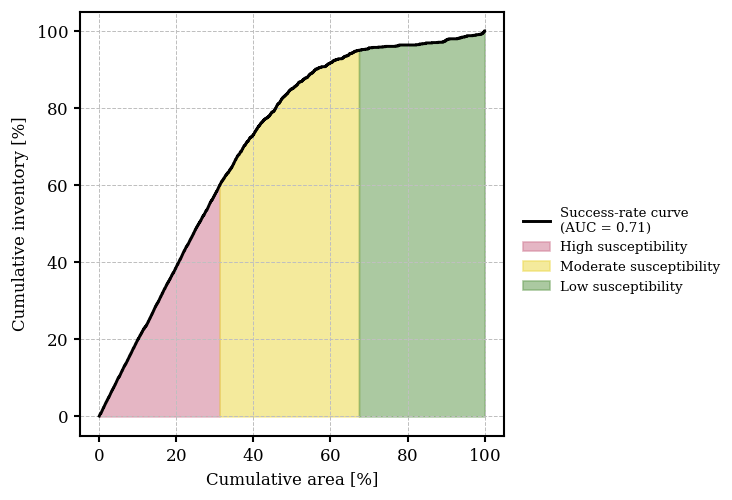

In [32]:
inventory = df_landslides.loc[~mask_nan].to_numpy(dtype=float)
zonation_index = df_cond_fact_w.loc[~mask_nan, "ISTZU"].to_numpy(dtype=float)

sorted_indices = np.argsort(zonation_index)[::-1]
sorted_index = zonation_index[sorted_indices]
sorted_inventory = inventory[sorted_indices]
total_inventory = sorted_inventory.sum()
if total_inventory <= 0:
    raise ValueError("The inventory has no mapped landslide cells.")

cumulative_inventory = np.cumsum(sorted_inventory) / total_inventory
cumulative_area = np.arange(1, sorted_index.size + 1) / sorted_index.size

idx_LM = min(np.searchsorted(cumulative_inventory, low_to_mod_perc / 100), sorted_index.size - 1)
idx_MH = min(np.searchsorted(cumulative_inventory, mod_to_high_perc / 100), sorted_index.size - 1)
threshold_LM = sorted_index[idx_LM]
threshold_MH = sorted_index[idx_MH]
susceptibility_thresholds = sorted([threshold_LM, threshold_MH])

roc_auc = roc_auc_score(inventory, zonation_index)
success_rate_auc = np.trapezoid(
    np.r_[0.0, cumulative_inventory],
    np.r_[0.0, cumulative_area],
)
print(f"ROC AUC: {roc_auc:.4f}; success-rate AUC: {success_rate_auc:.4f}")

fig, ax = plt.subplots(figsize=(6, 7.5), layout='constrained')
ax.plot(
    cumulative_area * 100,
    cumulative_inventory * 100,
    color="k",
    label=f"Success-rate curve\n(AUC = {success_rate_auc:.2f})",
)
ax.fill_between(cumulative_area[:idx_MH + 1] * 100, cumulative_inventory[:idx_MH + 1] * 100,
                color=colors[-1], alpha=0.6, label="High susceptibility")
ax.fill_between(cumulative_area[idx_MH:idx_LM + 1] * 100, cumulative_inventory[idx_MH:idx_LM + 1] * 100,
                color=colors[-2], alpha=0.6, label="Moderate susceptibility")
ax.fill_between(cumulative_area[idx_LM:] * 100, cumulative_inventory[idx_LM:] * 100,
                color=colors[0], alpha=0.6, label="Low susceptibility")
ax.set(xlabel="Cumulative area [%]", ylabel="Cumulative inventory [%]")
fig.legend(loc="outside center right", fontsize=8)
ax.grid(True)
ax.set_aspect("equal")
plt.show()

/tmp/ipykernel_61337/2902008703.py:10: UserWarning: The following kwargs were not used by contour: 'lw'
  landslide_contour = ax.contour(landslides, colors='black', alpha=0.5, origin='image', levels=[0.5], lw=1.5, extent=extent)


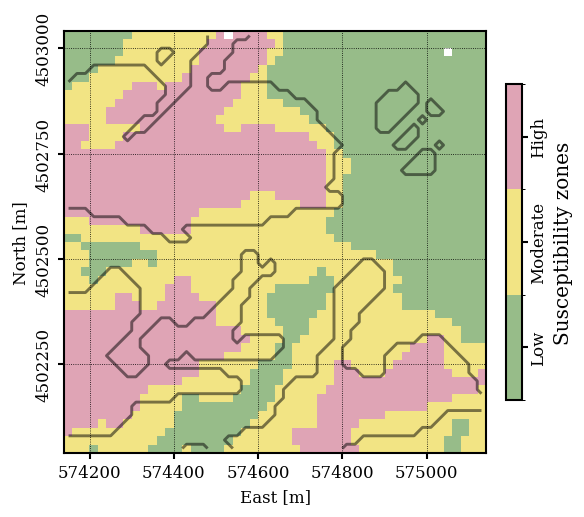

In [33]:
susceptibility_zonation = np.digitize(ISTZU, bins=susceptibility_thresholds, right=True).astype(float)
susceptibility_zonation[mask_nan_mtx] = np.nan

fig, ax = plt.subplots(1, 1, layout="constrained")  

# Plot rasters
# ax.imshow(HSD, cmap='Grays_r', alpha=1, extent=extent)
extent=(bounds.left, bounds.right, bounds.bottom, bounds.top)
im = ax.imshow(susceptibility_zonation, cmap=cmap_zones, norm=norm, alpha=0.75, extent=extent)
landslide_contour = ax.contour(landslides, colors='black', alpha=0.5, origin='image', levels=[0.5], lw=1.5, extent=extent)
# Add colorbar
cbar = plt.colorbar(im, ax=ax, orientation='vertical', shrink=0.75, pad=0.03, ticks=[0, 1, 2])
_ = cbar.ax.set_yticklabels(['Low', 'Moderate', 'High'])
cbar.set_label('Susceptibility zones', rotation=90, size="large")
cbar.ax.tick_params(axis="y", labelrotation=90, pad=1.5)
[label.set_va("center") for label in cbar.ax.get_yticklabels()]

# Figure aesthetics
ax.grid(True, ls=':', lw=0.5, color='k')
ax.spines[["bottom", "left"]].set_linewidth(AXIS_LINEWIDTH)
ax.set_xlabel('East [m]')
ax.xaxis.set_major_formatter(mpl.ticker.ScalarFormatter(useMathText=False))
ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=5))
ax.ticklabel_format(style='plain', axis='x')
ax.set_ylabel('North [m]')
ax.yaxis.set_major_formatter(mpl.ticker.ScalarFormatter(useMathText=False))
ax.ticklabel_format(style='plain', axis='y')  # or axis='x'
plt.setp(ax.get_yticklabels(), rotation=90, ha='right', va='center')
ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=4))
ax.tick_params(width=AXIS_LINEWIDTH)

plt.show()

In [27]:
if not testing_data:
    write_result(
        os.path.join(outputs_folder, "susceptibility_zonation.tif"),
        susceptibility_zonation,
        reference_grid,
    )